In [2]:
import numpy as np
import pandas as pd

In [3]:
# Reading the data
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

data = pd.read_csv("/Users/sriharika_jajula/Coding/heart_disease_prediction/Data/processed.cleveland.data", names = column_names)

description of the variable in the dataset

1. age:             represents the age of the patient in years (integer)
2. sex:             represents the gender of the patient (categorical variable) [1 = male, 0 = female]
3. cp:              represents the chest pain type experienced by the patient (categorical Variable) [1 = typical angina, 2 = atypical, angina, 3 - non anginal pain, 4 = asymptomatic pain]
4. trestbps:        represents the resting blood pressure of the patient in mm Hg (integer)
5. chol:            represents the serum cholesterol level of the patient in mg/dl (integer)
6. fbs:             represents whether the patient has fasting blood sugar > 120 mg/dl (categorical variable) [1 = true, 0 = false]
7. restecg:        represents the resting electrocardiographic results (categorical variable) [0 = normal, 1 = having ST-T wave abnormality, 2 = showing probable ]
8. thalach:        represents the maximum heart rate achieved by the patient (integer)
9. exang:          represents whether the patient has exercise-induced angina (categorical variable) [1 = yes, 0 = no]
10. oldpeak:        represents the ST depression induced by exercise relative to rest (integer)
11. slope:          represents the slope of the peak exercise ST segment (categorical variable) [1 = upsloping, 2 = flat, 3 = downsloping]
12. ca:             represents the number of major vessels colored by fluoroscopy (integer)
13. thal:           represents the thalassemia type (categorical variable) [3 = normal, 6 = fixed defect, 7 = reversible defect]
14. target: represents the target label indicating the diagnosis of heart disease (label) [0 = no heart disease, 1 = heart disease present]

In [4]:
print("no of rows in the dataset:",data.shape[0])
print("no of columns in the dataset:", data.shape[1])

no of rows in the dataset: 303
no of columns in the dataset: 14


In [5]:
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [7]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [8]:
data["target"].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

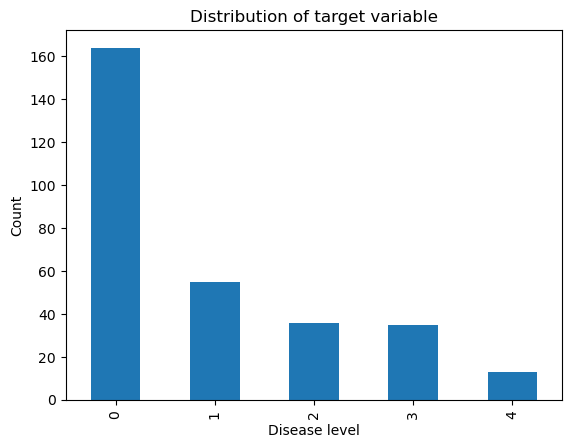

In [9]:
import matplotlib.pyplot as plt

data["target"].value_counts().plot(kind ="bar")
plt.title("Distribution of target variable")
plt.xlabel("Disease level")
plt.ylabel("Count")
plt.show()

The distribution of the target variable is as follows:
- class 0 has highest count of the data points indicating that most of the patients in the dataset do not have heart disease.


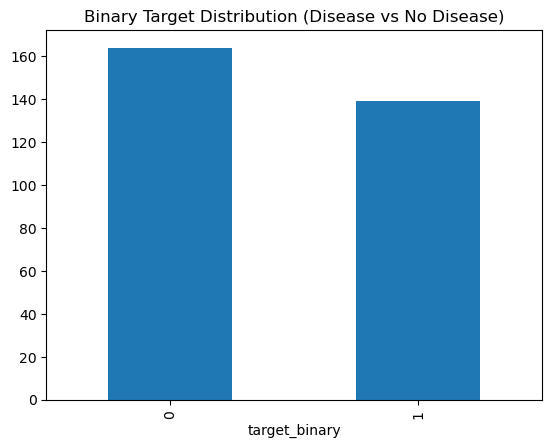

In [10]:
data['target_binary'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

data['target_binary'].value_counts().plot(kind='bar')
plt.title("Binary Target Distribution (Disease vs No Disease)")
plt.show()

When binary classification is performed by converting the target variable into a binary format [Disease or No Disease]. The data can be considered as balanced dataset.

In [11]:
(data['ca'] == "?").sum(), (data['thal'] == "?").sum()
print("percentage of missing values in the dataset is: ", ((data['ca'] == "?").sum() + (data['thal'] == "?").sum()) / data.shape[0] * 100)

percentage of missing values in the dataset is:  1.9801980198019802


Missing values were encoded as "?" in the dataset
Identified 4 missing values in 'ca' and 2 in 'thal'
As the percentage of missing values in the dataset is less than 5%
Choose to drop the rows as the missing values.

In [12]:
data = data.replace("?", np.nan)
data = data.dropna()
data = data.astype(float)

In [13]:
data.info()

<class 'pandas.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            297 non-null    float64
 1   sex            297 non-null    float64
 2   cp             297 non-null    float64
 3   trestbps       297 non-null    float64
 4   chol           297 non-null    float64
 5   fbs            297 non-null    float64
 6   restecg        297 non-null    float64
 7   thalach        297 non-null    float64
 8   exang          297 non-null    float64
 9   oldpeak        297 non-null    float64
 10  slope          297 non-null    float64
 11  ca             297 non-null    float64
 12  thal           297 non-null    float64
 13  target         297 non-null    float64
 14  target_binary  297 non-null    float64
dtypes: float64(15)
memory usage: 37.1 KB


Notes of the EDA process:

1. Dataset contains 303 observations and 14 variables before handling missing values.
2. Dataset contains 297 observations after handling missing values.
3. Missing values were encoded as "?" in the dataset in two variables ["ca" and "thal"].
4. All the variables in the dataset are of numeric type after handling missing values and converting them to float type.
5. Most of the patients in the dataset do not have heart disease.

Univariate Analysis: Examining the distribution of individual features in the dataset.

In [14]:
data["age"].describe()

count    297.000000
mean      54.542088
std        9.049736
min       29.000000
25%       48.000000
50%       56.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64

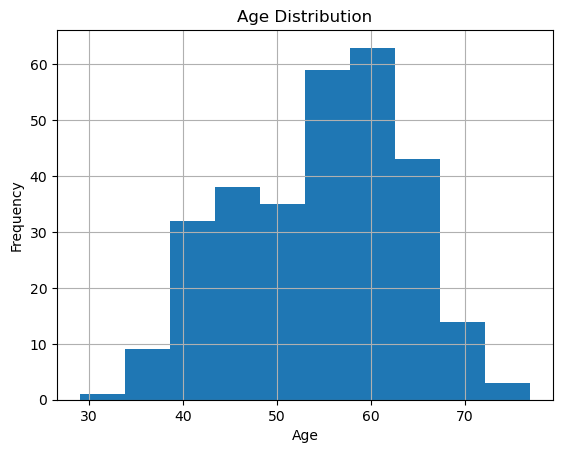

In [15]:
data["age"].hist(bins = 10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Age Distribution:
    Normal distribution with mean age around 54 years.

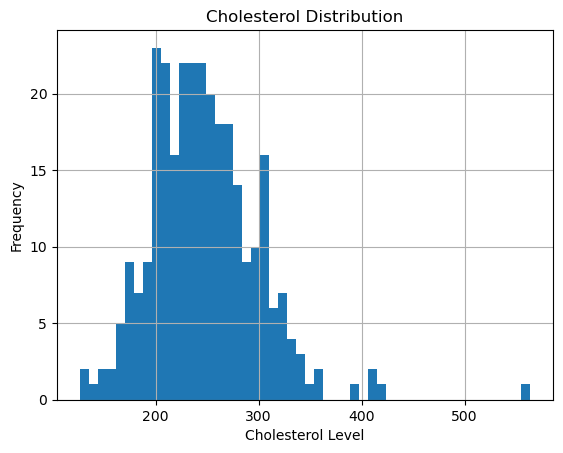

In [16]:
data["chol"].hist(bins = 50)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol Level")
plt.ylabel("Frequency")
plt.show() 

Cholesterol Distribution:
    Right-skewed distribution with mean cholesterol level around 250 mg/dl.

Text(0, 0.5, 'Frequency')

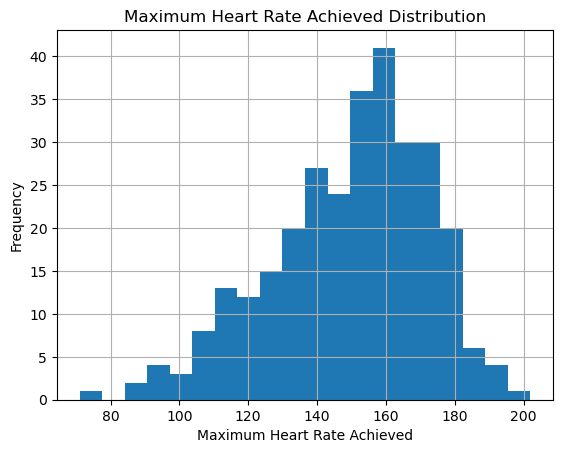

In [17]:
data["thalach"].hist(bins = 20)
plt.title("Maximum Heart Rate Achieved Distribution")
plt.xlabel("Maximum Heart Rate Achieved")
plt.ylabel("Frequency")

Maximum Heart Rate Achieved Distribution:
    left-skewed distribution with mean maximum heart rate achieved around 160 bpm.

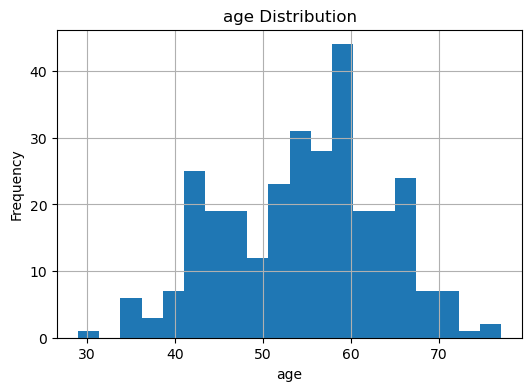

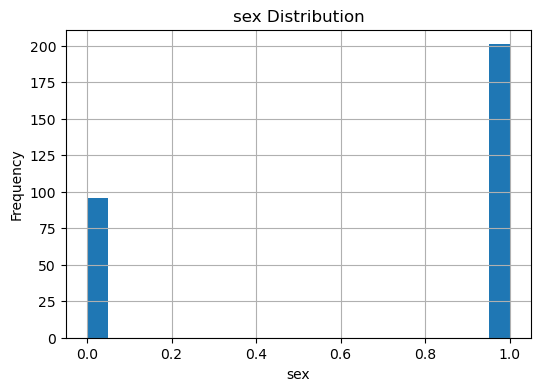

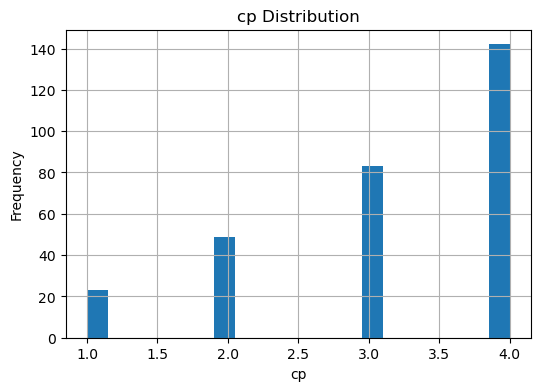

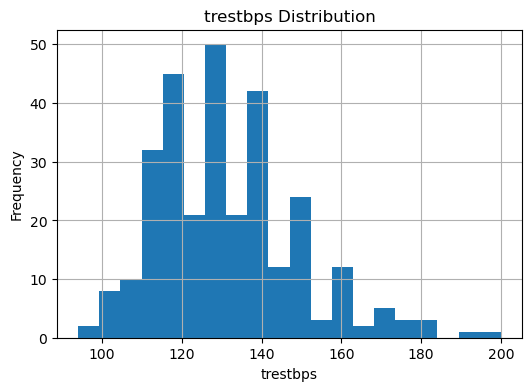

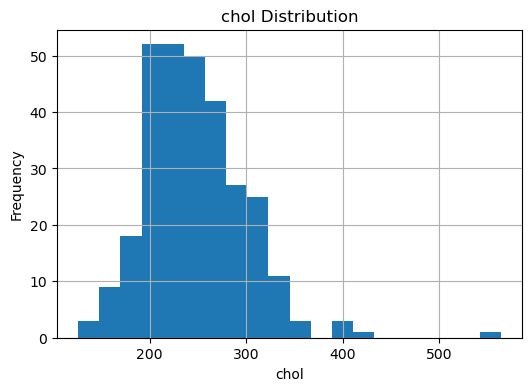

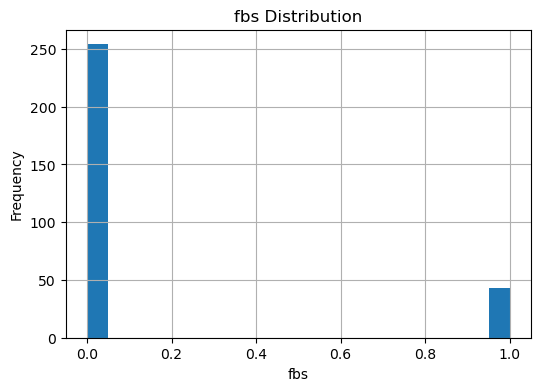

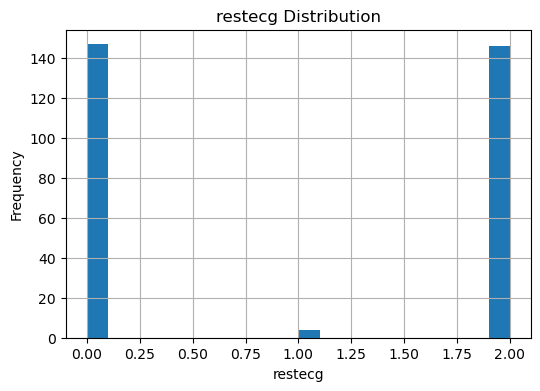

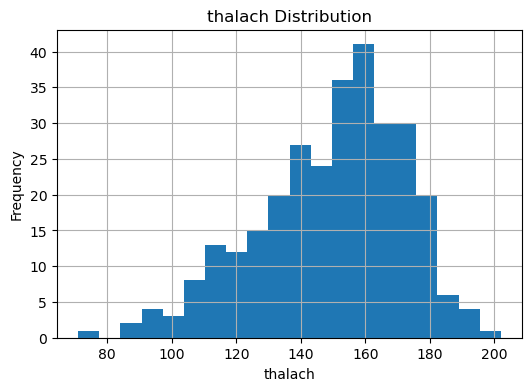

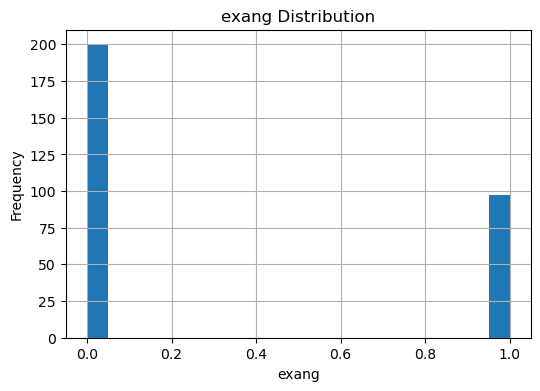

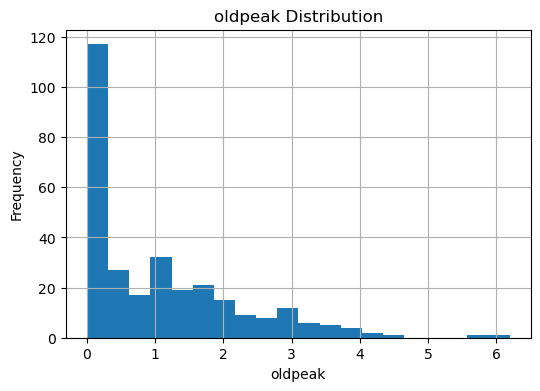

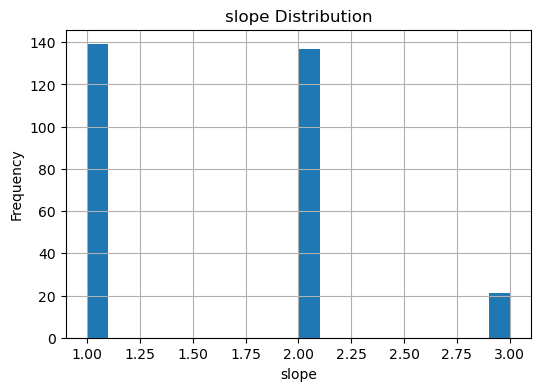

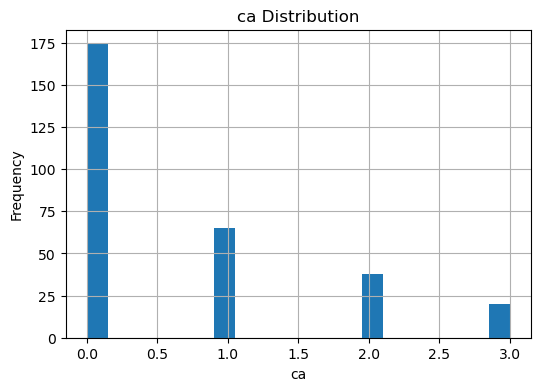

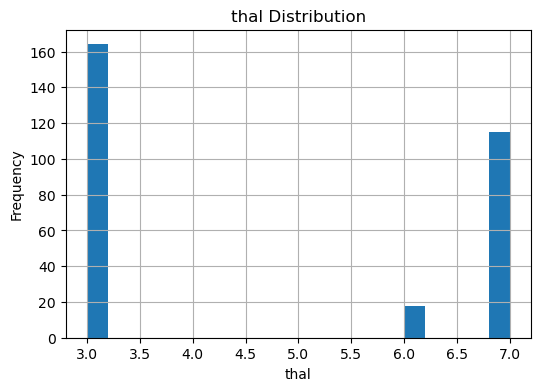

In [18]:
features = [col for col in data.columns if col not in ["target", "target_binary"]]

for feature in features:
    plt.figure(figsize = (6, 4))
    data[feature].hist(bins = 20)
    plt.title(f"{feature} Distribution")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

Univariate analysis of all features:
    Histograms of all features show varying distributions, with some features exhibiting skewness and others showing more normal distributions.

    Key observations from univariate analysis:
     1. Age: The range of the age for the patients in the dataset is between 20 and 80 years with maximum frequency around 50-60 years.

     2. Sex: The dataset contains more male patients than female patients, with a ratio of approximately 2:1 making it an imbalanced dataset.

     3. Chest pain (cp): There are four types of chest pains experienced by the paients in the dataset with the most common type being asymptomatic pain followed by non-anginal pain, atypical angina and typical angina.

     4. Resting blood pressur (trestbps): The resting blood pressure of the paients is a right-skewed distribution with most of the patients having resting blood pressure between 120 and 140 mm Hg.

     5. Cholesterol (chol): The cholesterol levels of the patients are also right-skewed distribution with most of the patients having cholesterol levels between 200 and 300 mg/dl.

     6. Fasting blood sugar (fbs):  Most of the patients have this value as 0 indicating that they have fasting blood sugar < 120 mg/dl. which is the case of healthy patients in general.

     7. Resting electrocardiographic results (restecg): Most common occurence of restecg is in two categories [ 0 and 2] wit very few patients having restecg value of 1 which seems to be an uneven distribution with respect to this feature.

     8. Maximum heart rate achieved (thalach): The maximum heart rate achieved by the patients is a left-skewed distribution with values ranging between 70 and 200 bpm. Maximum frequency of patients is observed between 150 and 180 bpm.

     9. Exercise-induced angina (exang): Most of the patients in the dataset do not have exercise-induced angina with feature value corresponding to 0.

     10. Oldpeak: The ST depression induced by exercise relative to rest is a right-skewed distribution with most of the patients having oldpeak values between 0 and 1.

     11. Slope: Being a categorical variable, there are three categories of slope with the most common category being 2 and 1 followed by 3.

     12. Number of major vessels colored by fluoroscopy (ca): The number of major vessels colored by fluoroscopy is a right-skewed distribution with most of the patients having 0 or 1 major vessel colored.

     13. Thalassemia type (thal): The thalassemia type is a categorical variable with three categories [3, 6, 7] with the most common category being 3 and 6 with very few patien ts having thal value of 7.

These observations from the univariate analysis provide insights into the distribution of individual features in the dataset, which can be useful for further analysis and modeling.

Bi Variate Analysis: Examining the relationship between feature and the target variable in the dataset.

In [19]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
continuos_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

<Axes: xlabel='cp'>

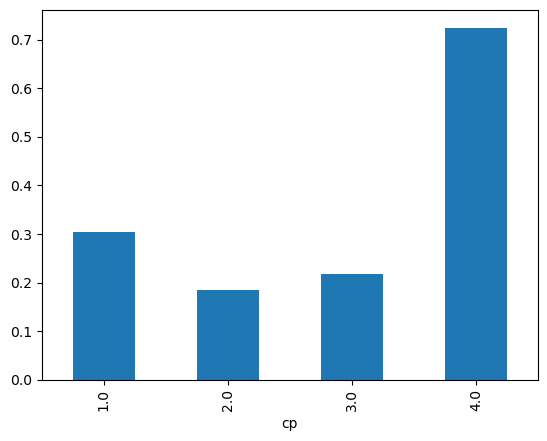

In [20]:
data.groupby('cp')['target_binary'].mean().plot(kind='bar')

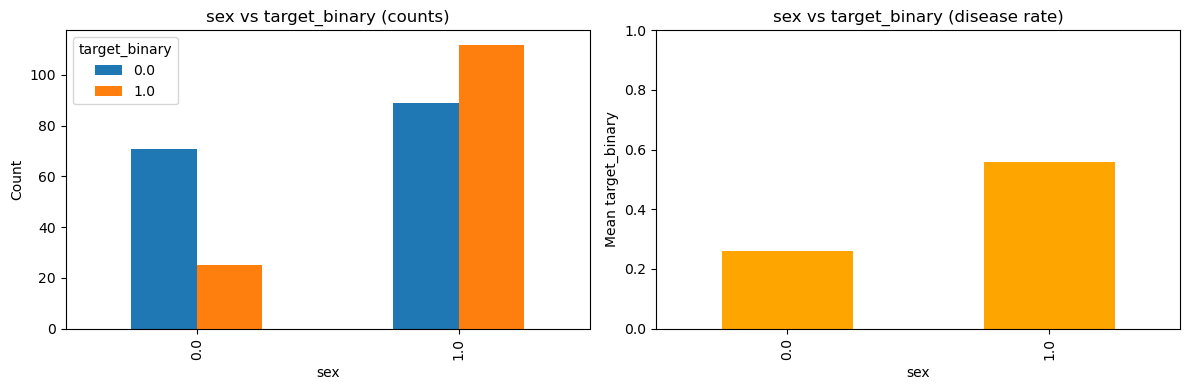

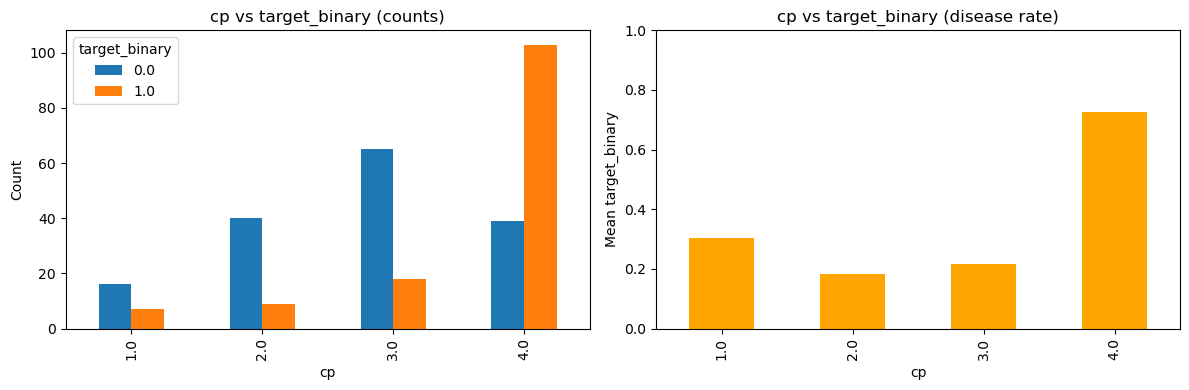

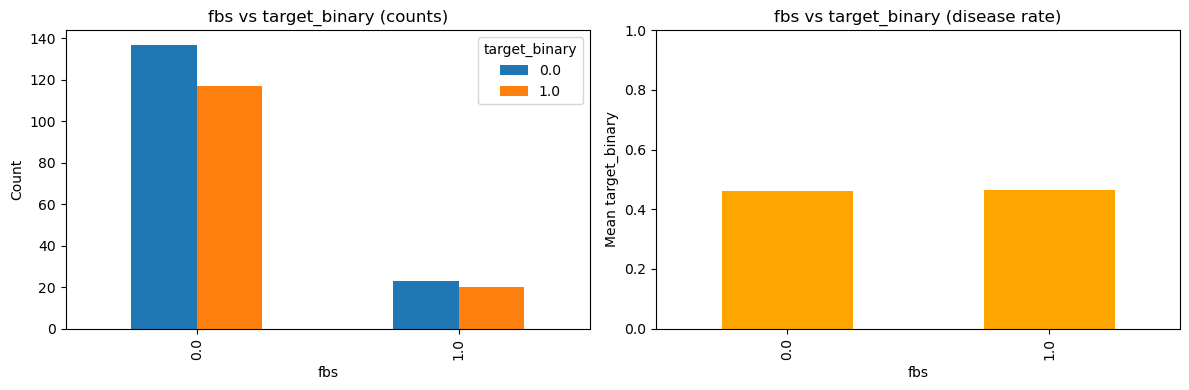

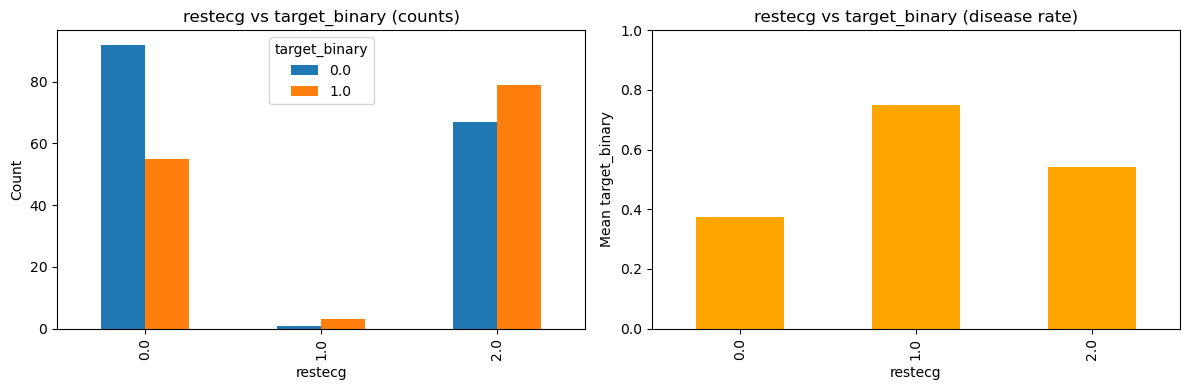

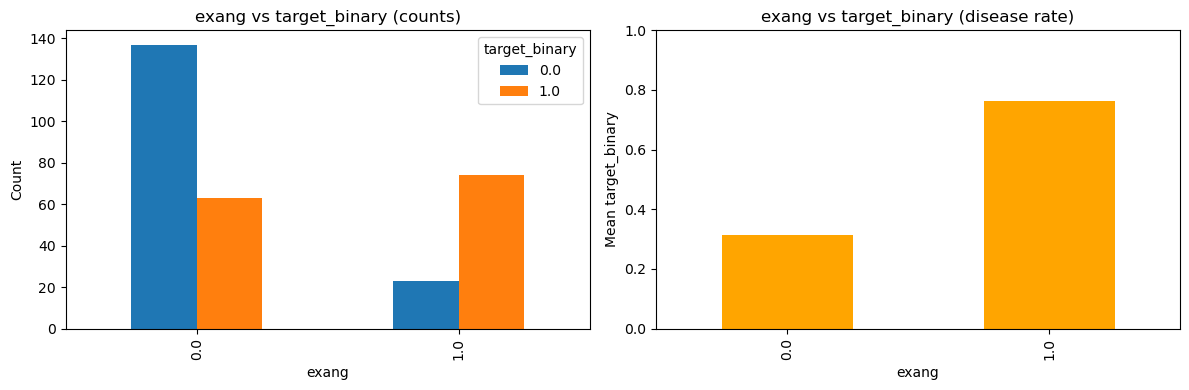

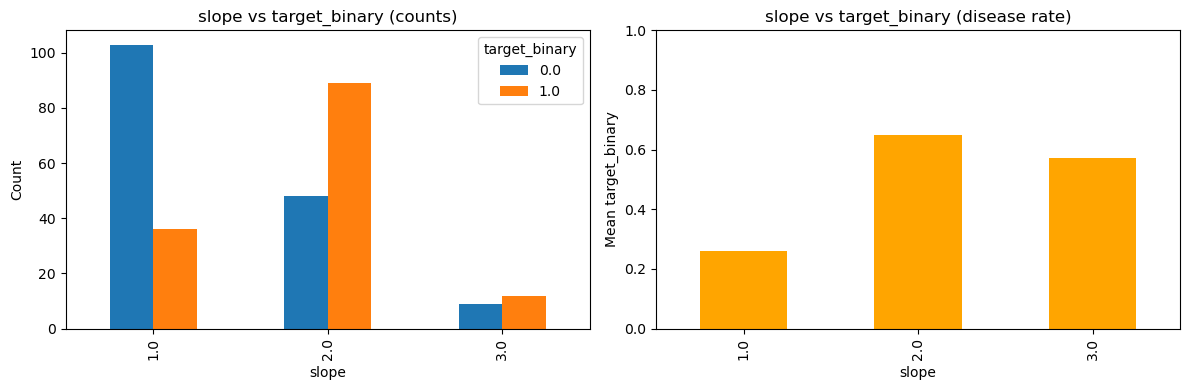

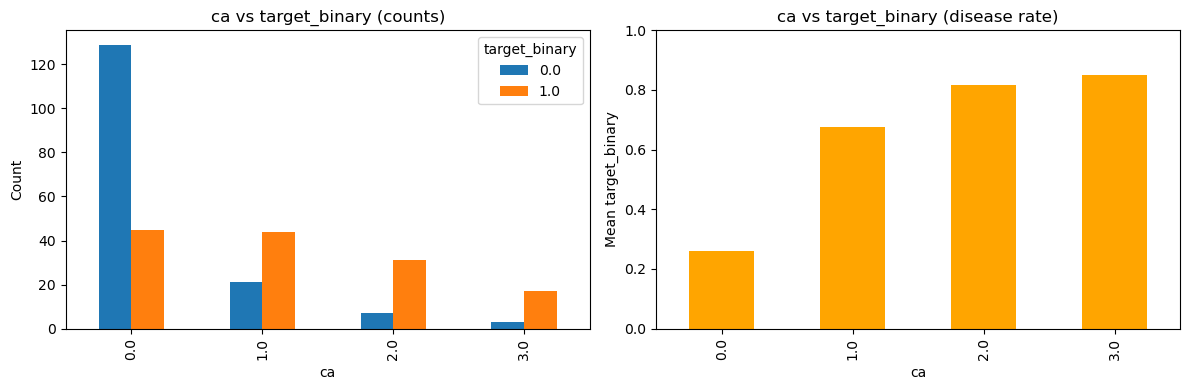

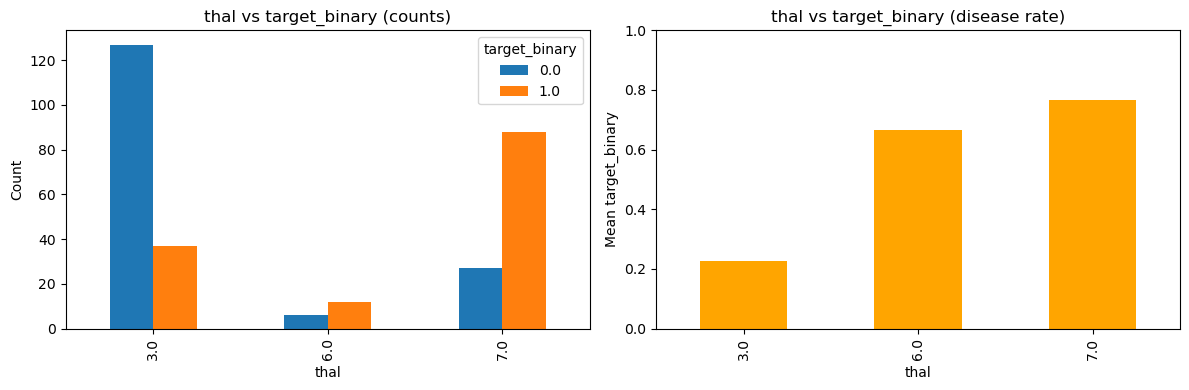

In [21]:
for col in categorical_features:
    fig, axes = plt.subplots(1, 2, figsize = (12, 4))

    #counting distribution by target class
    pd.crosstab(
        data[col], 
        data["target_binary"]
        ).plot(kind = "bar", ax = axes[0])
    
    axes[0].set_title(f"{col} vs target_binary (counts)")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")
    axes[0].legend(title = "target_binary")

    #Probability of disease (Mean target rate)
    data.groupby(col)["target_binary"].mean().plot(
        kind = "bar",
        ax = axes[1],
        color = "orange"
    )
    axes[1].set_title(f"{col} vs target_binary (disease rate)")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Mean target_binary")
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

Observations from bivariate analysis of categorical features with respect to the target variable:
    1. Sex: 
        > Male patients(sex = 1) have higher probability of having heart disease compared to female patients(sex = 0).
    2. Chest pain (cp): 
        > Patients with asymptomatic chest pain (cp = 4) have the highest probability (approx 75%) of having heart disease.
    3. Fasting blood sugar (fbs): 
        > Patients with fasting blood sugar of two categories (fbs = 0 and fbs = 1) have similar probability of having heart disease.
    4. resting ECG (restecg):
        > Patient with restecg = 1 have higher probability of having heart disease compared to patients with restecg = 0 and restecg = 2 but has lower count of patients in the dataset.
    5. Exercise-induced angina (exang):
        > Patients with exercise-induced angina (exang = 1) have higher probability (around 80%) of having heart disease when compared to patients without exercise-induced angina (exang = 0).
    6. Slope:
        > Patients with slope = 2 has the highest risk of having heart disease 
        > All the three categories of slope have similar probability of having heart disease indicating that slope may be a meaningful feature.
    7. Number of major vessels colored by fluoroscopy (ca):
        > All the categories of ca have similar and high probability of having heart disease indicating that ca may be a meaningful feature.
    8. Thalassemia type (thal):
        > Patients with thalassemia type of 6 and 7 have higher probability of having heart disease compared to patients with thalassemia type of 3.

The summary of the key inferences from the bivariate analysis of categorical features:
    - Strong predictors: cp, ca, thal, exang, slope
    - Moderate predictors: sex, restecg
    - Weak predictors: fbs

These observations can help in feature selection and engineering for building predictive models for heart disease diagnosis.


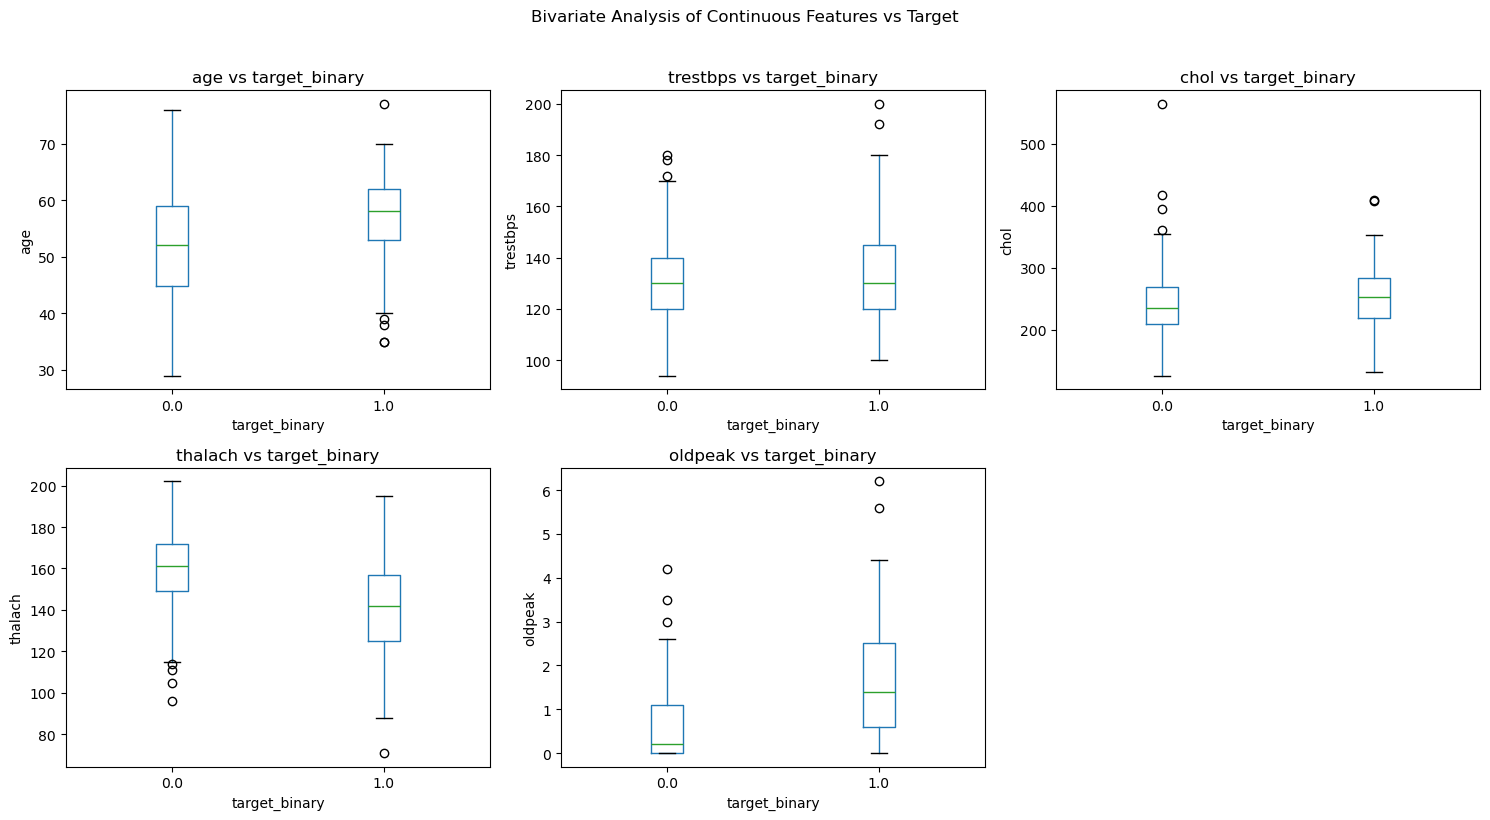


age:
target_binary
0.0    52.643750
1.0    56.759124
Name: age, dtype: float64

trestbps:
target_binary
0.0    129.175000
1.0    134.635036
Name: trestbps, dtype: float64

chol:
target_binary
0.0    243.493750
1.0    251.854015
Name: chol, dtype: float64

thalach:
target_binary
0.0    158.581250
1.0    139.109489
Name: thalach, dtype: float64

oldpeak:
target_binary
0.0    0.598750
1.0    1.589051
Name: oldpeak, dtype: float64


In [22]:
fig, axes = plt.subplots(2, 3, figsize = (15, 8))
axes = axes.flatten()

for i, col in enumerate(continuos_features):
    data.boxplot(column = col, by = "target_binary", ax = axes[i], grid = False)
    axes[i].set_title(f"{col} vs target_binary")
    axes[i].set_xlabel("target_binary")
    axes[i].set_ylabel(col)

for j in range(len(continuos_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Bivariate Analysis of Continuous Features vs Target", y = 1.02)
plt.tight_layout()
plt.show()

for col in continuos_features:
    print(f"\n{col}:")
    print(data.groupby("target_binary")[col].mean())

Bivariate Analysis of continuous features with respect to the target variable:
    1. Age: 
        > Patients with heart disease have higher mean age compared to patients without heart disease. Indicating that risk of heart disease increases with age.
    2. Resting blood pressure (trestbps):
        > Patients with heart disease have higher mean resting blood pressure compared to patients without heart disease.
    3. Cholesterol (chol):
        > Patients with heart disease have higher mean cholesterol levels compared to patients without heart disease.
    4. Maximum heart rate achieved (thalach):
        > Patients with heart disease have lower mean maximum heart rate achieved compared to patients without heart disease.
    5. Oldpeak:
        > Patients with heart disease have higher mean oldpeak values compared to patients without heart disease.

The summary of the key inferences from the bivariate analysis of continuous features:
    - Strong predictors: Thalach, old peak
    - Moderate predictors: age
    - Weak predictors: trestbps, chol

These observations can help in feature selection and engineering for building predictive models for heart disease diagnosis.


In [23]:
data.info()

<class 'pandas.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            297 non-null    float64
 1   sex            297 non-null    float64
 2   cp             297 non-null    float64
 3   trestbps       297 non-null    float64
 4   chol           297 non-null    float64
 5   fbs            297 non-null    float64
 6   restecg        297 non-null    float64
 7   thalach        297 non-null    float64
 8   exang          297 non-null    float64
 9   oldpeak        297 non-null    float64
 10  slope          297 non-null    float64
 11  ca             297 non-null    float64
 12  thal           297 non-null    float64
 13  target         297 non-null    float64
 14  target_binary  297 non-null    float64
dtypes: float64(15)
memory usage: 37.1 KB


In [24]:
data.to_csv("/Users/sriharika_jajula/Coding/heart_disease_prediction/Data/cleaned_heart_disease_data.csv", index = False)